# **Iris Flower Classification**
*   Use measurements of Iris flowers (setosa, versicolor, virginica) as input data.
*   Train a machine learning model to classify the species based on these measurements.
*   Train a machine learning model to classify the species based on these measurements.
*   Use libraries like Scikit-learn for easy dataset access and model building.
*   Evaluate the model’s accuracy and performance using test data.
*   Understand basic classification concepts in machine learning.






## Import Libraries

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")

## Data Processing

In [33]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Data Cleaning

In [34]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [35]:
print(df.shape)
print(df['species'].value_counts())

(150, 5)
species
0    50
1    50
2    50
Name: count, dtype: int64


In [36]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Exploratory Data Analysis

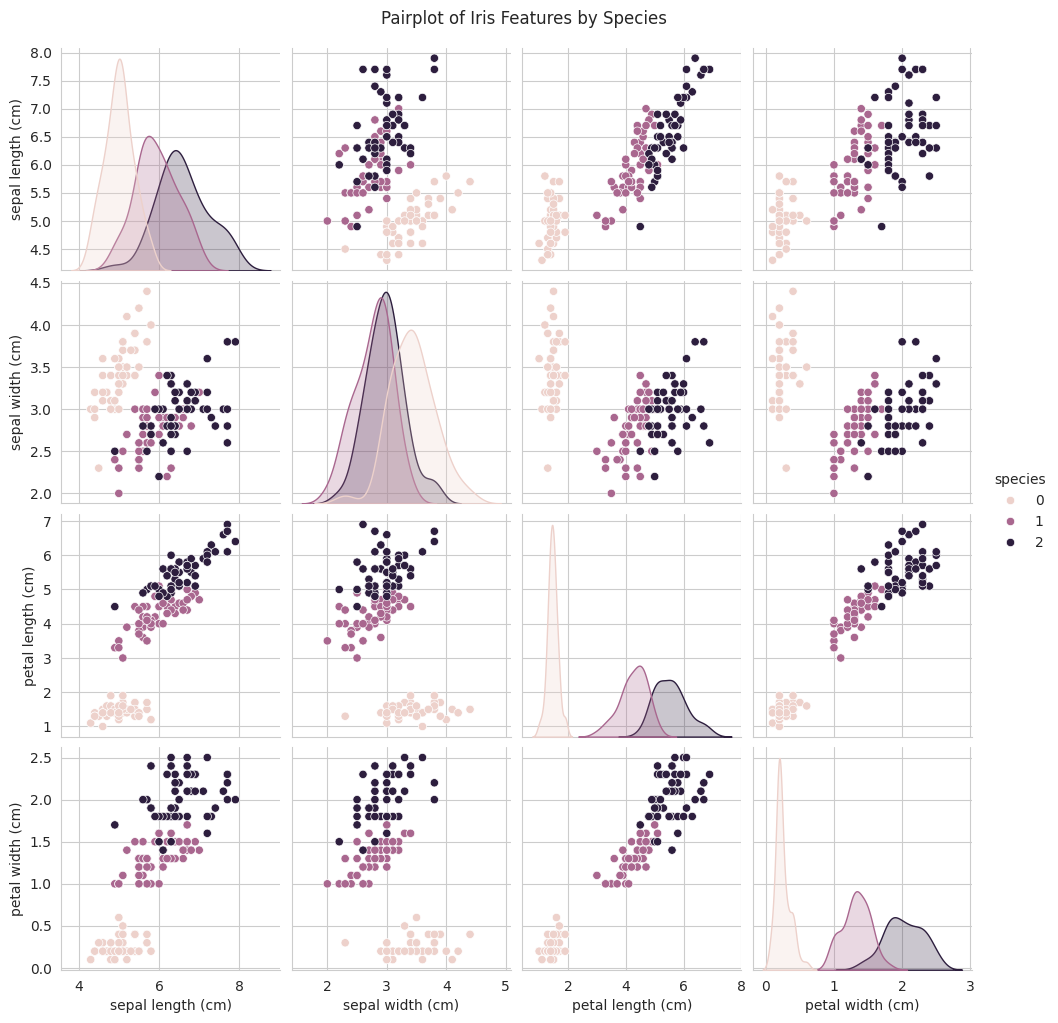

In [37]:
sns.pairplot(df, hue='species', vars=iris.feature_names)
plt.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

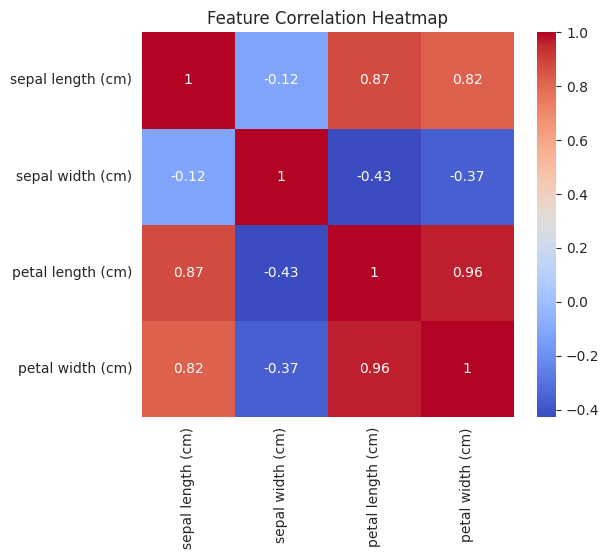

In [38]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

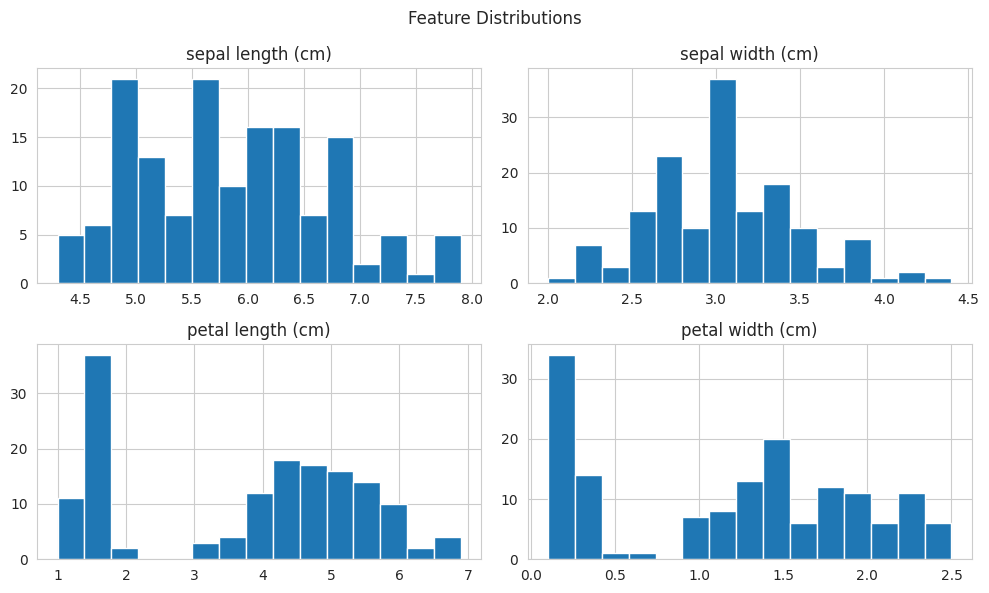

In [39]:
df.iloc[:, :4].hist(figsize=(10, 6), bins=15)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

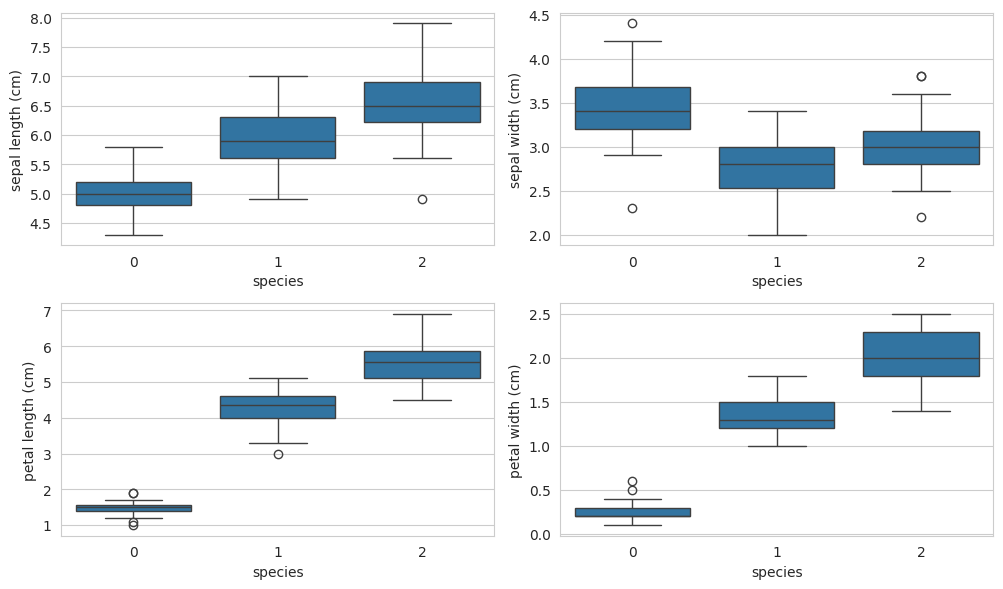

In [50]:
plt.figure(figsize=(10, 6))
for i, col in enumerate(iris.feature_names):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x='species', y=col, data=df)
plt.tight_layout()
plt.show()

## Statistical Testing

In [51]:
alpha = 0.05
results_stats = []

for feature in iris.feature_names:
    groups = [df[df['species'] == sp][feature] for sp in df['species'].unique()]

    normal = all(stats.shapiro(g)[1] >= alpha for g in groups)
    equal_var = stats.levene(*groups)[1] >= alpha

    if normal and equal_var:
        test_name = "One-Way ANOVA"
        stat, p = stats.f_oneway(*groups)
    else:
        test_name = "Kruskal-Wallis"
        stat, p = stats.kruskal(*groups)

    decision = "Reject H0" if p < alpha else "Fail to Reject H0"
    results_stats.append({"Feature": feature, "Test Used": test_name,
                           "Statistic": round(stat, 4), "p-value": round(p, 8),
                           "Decision": decision})

stats_results_df = pd.DataFrame(results_stats)
stats_results_df

,Feature,Test Used,Statistic,p-value,Decision
0,sepal length (cm),Kruskal-Wallis,96.9374,0.0,Reject H0
1,sepal width (cm),One-Way ANOVA,49.1600,0.0,Reject H0
2,petal length (cm),Kruskal-Wallis,130.4110,0.0,Reject H0
3,petal width (cm),Kruskal-Wallis,131.1854,0.0,Reject H0


## Data Preprocessing

In [45]:
X = df[iris.feature_names]
y = df['species']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training samples: ", X_train.shape[0])
print("Testing samples: ", X_test.shape[0])

Training samples:  120
Testing samples:  30


## Data Modelling

In [53]:
models = {
    "Logistic Regression": Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=200))]),
    "Decision Tree": Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))]),
    "Random Forest": Pipeline([('scaler', StandardScaler()), ('clf', RandomForestClassifier(random_state=42))]),
    "KNN": Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())]),
    "SVM": Pipeline([('scaler', StandardScaler()), ('clf', SVC())]),
    "Naive Bayes": Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())]),
}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)

print("All models trained successfully.")

All models trained successfully.


## Data Evaluation

In [54]:
def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='macro'),
        "Recall": recall_score(y_test, y_pred, average='macro'),
        "F1-Score": f1_score(y_test, y_pred, average='macro'),
    }

results = [evaluate_model(name, pipe, X_test, y_test) for name, pipe in models.items()]
results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score
0,SVM,0.9667,0.9697,0.9667,0.9666
1,Naive Bayes,0.9667,0.9697,0.9667,0.9666
2,Decision Tree,0.9333,0.9333,0.9333,0.9333
3,Logistic Regression,0.9333,0.9333,0.9333,0.9333
4,KNN,0.9333,0.9444,0.9333,0.9327
5,Random Forest,0.9000,0.9024,0.9000,0.8997


In [55]:
for name, pipeline in models.items():
    y_pred = pipeline.predict(X_test)
    print(f"\nConfusion Matrix - {name}")
    print(confusion_matrix(y_test, y_pred))


Confusion Matrix - Logistic Regression
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Confusion Matrix - Decision Tree
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Confusion Matrix - Random Forest
[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]

Confusion Matrix - KNN
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

Confusion Matrix - SVM
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Confusion Matrix - Naive Bayes
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [56]:
best_model_name = results_df.iloc[0]["Model"]
best_pipeline = models[best_model_name]

print(f"Best performing model: {best_model_name}")
print(f"Accuracy achieved: {results_df.iloc[0]['Accuracy']:.4f}")
print(classification_report(y_test, best_pipeline.predict(X_test)))

Best performing model: SVM
Accuracy achieved: 0.9667
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



# Testing

In [57]:
new_flower = pd.DataFrame([[5.9, 3.0, 4.2, 1.5]], columns=iris.feature_names)
predicted_species = best_pipeline.predict(new_flower)
print(f"Predicted species: {predicted_species[0]}")

Predicted species: 1


This project classifies Irir flowers into three species (satosa, versicolor, virginica) using four measurements: sepal length, sepal width, petal length, and petal width. Six machine learning models were terainsed and compared, with SVM achieving the best accuracy of 96.67% on unseen test data.